In [2]:
import numpy as np

In [14]:
# Converting normal lists to numpy arrays
a = [1,2,3,4,5,6]
a = np.array(a)
a
# To convert back to the list from numpy 
b = a.tolist()
a, b

(array([1, 2, 3, 4, 5, 6]), [1, 2, 3, 4, 5, 6])

In [3]:
# getting dataset and using it in nparray 
URL = "https://www.ncei.noaa.gov/pub/data/cdo/samples/GHCND_sample_csv.csv"
raw = np.loadtxt(URL, delimiter=",", usecols=[6,7,8], skiprows=1)

raw


array([[-1.780e+02, -3.110e+02,  0.000e+00],
       [-2.440e+02, -3.220e+02,  0.000e+00],
       [-1.940e+02, -2.890e+02,  0.000e+00],
       [-1.670e+02, -2.000e+02,  1.500e+01],
       [-1.330e+02, -1.670e+02,  9.999e+03],
       [-1.330e+02, -1.720e+02,  9.999e+03],
       [-1.500e+02, -2.780e+02,  0.000e+00],
       [-2.330e+02, -3.280e+02,  0.000e+00],
       [-2.330e+02, -3.220e+02,  0.000e+00],
       [-1.170e+02, -2.440e+02,  0.000e+00],
       [-6.700e+01, -1.280e+02,  0.000e+00],
       [-7.800e+01, -1.220e+02,  0.000e+00],
       [-1.700e+01, -8.900e+01,  0.000e+00],
       [ 3.900e+01, -7.200e+01,  0.000e+00],
       [-6.700e+01, -7.200e+01,  0.000e+00],
       [ 2.200e+01, -5.000e+01,  0.000e+00],
       [ 3.300e+01, -4.400e+01,  0.000e+00],
       [ 6.000e+00, -1.720e+02,  0.000e+00],
       [-5.600e+01, -1.830e+02,  0.000e+00],
       [-6.700e+01, -1.390e+02,  0.000e+00],
       [-6.700e+01, -9.400e+01,  2.500e+01],
       [-4.400e+01, -6.700e+01,  0.000e+00],
       [-6

In [6]:
# converting a normal csv table to numpy array
week_one_tmax = raw[0:7,0]
week_one_tmin = raw[0:7,1]
week_one_prcp = raw[0:7,2]

print(week_one_tmax)
print(week_one_tmin)
print(week_one_prcp)
print(week_one_prcp.shape) # Shows the dimension and size of the array

[-178. -244. -194. -167. -133. -133. -150.]
[-311. -322. -289. -200. -167. -172. -278.]
[   0.    0.    0.   15. 9999. 9999.    0.]
(7,)


In [ ]:
# Math operations work by making two array the same size and performing the particular function
# The method where numpy tries to match the dimension is called "broadcasting"
# Lets try converting the previous temperatures to celcius 
week_one_tmin = week_one_tmin / 10
week_one_tmax = week_one_tmax / 10
print(week_one_tmax)
print(week_one_tmin)

[-17.8 -24.4 -19.4 -16.7 -13.3 -13.3 -15. ]
[-31.1 -32.2 -28.9 -20.  -16.7 -17.2 -27.8]


In [11]:
# There are aggregation functions in numpy 
print("Minimum temperature across the week: " + str(np.min(week_one_tmin)))
print("Maximum temperature across the week: " + str(np.max(week_one_tmax)))

Minimum temperature across the week: -32.2
Maximum temperature across the week: -13.3


In [ ]:
# Dividing by zero
temp = week_one_tmax / 0
temp # Gives "inf"

C:\Users\User\AppData\Local\Temp\ipykernel_64132\523534968.py:2: RuntimeWarning: divide by zero encountered in divide
  temp = week_one_tmax / 0


array([-inf, -inf, -inf, -inf, -inf, -inf, -inf])

In [15]:
# Conditional Operations 
print(a)
print(a>4)

[1 2 3 4 5 6]
[False False False False  True  True]


In [ ]:
# Cases where broadcasting does not occur automatically 
a = np.array([1,2,3,4,5,6])
b = np.array([1,2,3])
print(a+b)

ValueError: operands could not be broadcast together with shapes (6,) (3,) 

In [19]:
# Slicing and indexing is the same as normal python lists
# Boolean Indexing is new 
# Using the previous example lets use the precipitation to determine no rain
no_rain = week_one_prcp == 0
print(week_one_prcp)
print(no_rain)
print("TMAX on no rain:", week_one_tmax[no_rain])
print("TMIN on no rain:", week_one_tmin[no_rain])


[   0.    0.    0.   15. 9999. 9999.    0.]
[ True  True  True False False False  True]
TMAX on no rain: [-17.8 -24.4 -19.4 -15. ]
TMIN on no rain: [-31.1 -32.2 -28.9 -27.8]


In [ ]:
# turning a 1d array to 2d
a = np.array([1, 2, 3, 4, 5, 6])
a = a.reshape(3, 2) # here if u put -1 instead of 2 then it would have automaitcally been reshaped
print(a)
print("shape:", a.shape)

[[1 2]
 [3 4]
 [5 6]]
shape: (3, 2)


In [ ]:
# Using axis to determine where to aggregate
print("Min along axis 0 (columns):", np.min(raw, axis=0)) # lowest among tmax,tmin,prcp
print("Min along axis 1 (rows):", np.min(raw, axis=1)) # Kinda useless cuz no relation

Min along axis 0 (columns): [-244. -328.    0.]
Min along axis 1 (rows): [-311. -322. -289. -200. -167. -172. -278. -328. -322. -244. -128. -122.
  -89.  -72.  -72.  -50.  -44. -172. -183. -139.  -94.  -67.  -44.  -11.
 -161. -233. -222. -283. -283. -267. -272.]


In [24]:
# 2D indexing is slighty different in numpy 
print("2nd row, 3rd column: ", raw[1,2]) # This is the same as raw[1][2] in normal list
# Also you can use a 1d list in the particular axis to select indexes specifically 
print("everything about row 1 and 3:", raw[[0,2]])
print("All rows only col 1 and 2:", raw[:,[0,1]])

2nd row, 3rd column:  0.0
everything about row 1 and 3: [[-178. -311.    0.]
 [-194. -289.    0.]]
All rows only col 1 and 2: [[-178. -311.]
 [-244. -322.]
 [-194. -289.]
 [-167. -200.]
 [-133. -167.]
 [-133. -172.]
 [-150. -278.]
 [-233. -328.]
 [-233. -322.]
 [-117. -244.]
 [ -67. -128.]
 [ -78. -122.]
 [ -17.  -89.]
 [  39.  -72.]
 [ -67.  -72.]
 [  22.  -50.]
 [  33.  -44.]
 [   6. -172.]
 [ -56. -183.]
 [ -67. -139.]
 [ -67.  -94.]
 [ -44.  -67.]
 [  -6.  -44.]
 [   0.  -11.]
 [ -11. -161.]
 [-161. -233.]
 [-167. -222.]
 [-167. -283.]
 [-189. -283.]
 [-156. -267.]
 [-150. -272.]]


There are 3 common ways for Advanced Indexing 
1) Multiple rows, single column
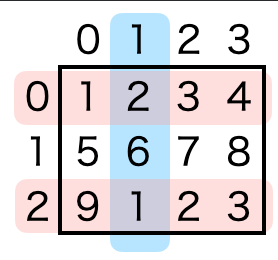

2)  Single row, multiple columns
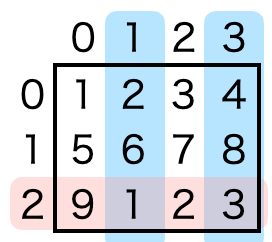

3) Multiple rows, multiple columns
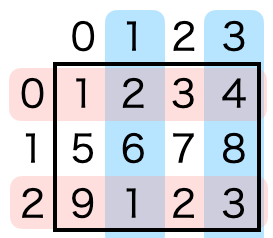




In [33]:
# Advanced Indexing 
a = np.array([
    [1, 2, 3, 4],
    [5, 6, 7, 8],
    [9, 1, 2, 3]
])

# 1) Multiple rows, single column
print("Multiple rows, single column")
# This returns shape (1, 2)
print(a[[[0], [2]], 1])
# This returns shape (2,)
print(a[[0, 2], 1]) # Brackets matter 

# 2) Single row, multiple columns
print("Single row, multiple columns")
# This returns shape (1, 2)
print(a[2, [[1, 3]]])
# This returns shape (2,)
print(a[2, [1, 3]])

# 3) Multiple rows, multiple columns
print("Multiple rows, multiple columns")
print(a[[[0], [2]], [[1, 3]]])
print(a[[0, 2], [1, 3]]) # By doing this, a[0, 1] and a[2, 3] will be selected.

# USING .ix_
# The following two are the same
print("USING .ix_")
idx = np.ix_([0, 2], [1, 3])
print(a[idx])
print(a[[[0], [2]], [1, 3]])

Multiple rows, single column
[[2]
 [1]]
[2 1]
Single row, multiple columns
[[1 3]]
[1 3]
Multiple rows, multiple columns
[[2 4]
 [1 3]]
[2 3]
USING .ix_
[[2 4]
 [1 3]]
[[2 4]
 [1 3]]


In [34]:
# Slicing is the same with python lists but only difference is the [,] comma    
X_extracted = raw[:5]
print(X_extracted)

print(raw[np.ix_([True, True, False, False, False], [True, False, True])])

[[-178. -311.    0.]
 [-244. -322.    0.]
 [-194. -289.    0.]
 [-167. -200.   15.]
 [-133. -167. 9999.]]
[[-178.    0.]
 [-244.    0.]]


In [ ]:
# Advanced stuffs with numpy 
from numpy import random
# Generate a uniform random number between [0, 1). 0 is included, but 1 is not.
print(random.rand())

# If a shape is provided as an argument, a uniform random array with that shape is generated
print(random.rand(5)) # A 1-dimensional array with length 5 (= shape (5, ))
print(random.rand(5, 5)) # A 2-dimensional array with shape (5, 5)

print(random.randint(4)) # Generate a random integer between 0 and 3
print(random.randint(2, 10, (3, 3))) # Generate a 2-dimensional array with shape (3, 3) containing random integers between 2 and 9



0.6433042191944823
[0.90790768 0.10832259 0.61931606 0.12126759 0.24164831]
[[0.95837603 0.58940005 0.56045828 0.82586581 0.72088797]
 [0.83750121 0.53917297 0.20570227 0.20182136 0.99446804]
 [0.79249945 0.01895587 0.71791205 0.47298367 0.71337169]
 [0.02610242 0.97861982 0.87616527 0.13549097 0.51431893]
 [0.97153322 0.25158528 0.60779579 0.56931191 0.0605651 ]]


In [36]:
# Matrix Calculation

x = np.arange(1, 4)
y = np.arange(6, 9)
A = np.arange(1, 10).reshape(3, 3)
B = random.randint(1, 10, (3, 3))

print("x:", x)
print("y:", y)
print("A:", A)
print("B:", B)

# The following two are the same TRASPOSING
print(np.transpose(A))
print(A.T)


print("Dot product of x and y")
print(np.dot(x, y))
print(np.matmul(x, y))
print(x @ y)

print("Matrix multiplication of A and B")
print(np.dot(A, B))
print(np.matmul(A, B))
print(A @ B)



x: [1 2 3]
y: [6 7 8]
A: [[1 2 3]
 [4 5 6]
 [7 8 9]]
B: [[4 4 3]
 [2 4 3]
 [8 3 6]]
[[1 4 7]
 [2 5 8]
 [3 6 9]]
[[1 4 7]
 [2 5 8]
 [3 6 9]]
Dot product of x and y
44
44
44
Matrix multiplication of A and B
[[ 32  21  27]
 [ 74  54  63]
 [116  87  99]]
[[ 32  21  27]
 [ 74  54  63]
 [116  87  99]]
[[ 32  21  27]
 [ 74  54  63]
 [116  87  99]]


In [37]:
# A simple example of broadcasting
print(np.matmul(A, x)) # x is interpreted as a column vector
print(np.matmul(x, A)) # x is interpreted as a row vector

[14 32 50]
[30 36 42]


In [38]:
# Side Note: Row vectors vs. Column vectors

a = np.array([1, 0, 1, 0, 1]) # A 5-dimensional vector represented as a 1-dimensional array

# The transpose doesn't change anything (since there is only one axis)
print("Before transpose:", a)
print("After transpose:", a.T)

# By converting it into a 2-dimensional array, column and row vectors can be distinguished

# Convert a into a row vector as a 2-dimensional array
a = a.reshape(1, -1) # Using -1 for the axis automatically calculates the number of elements
print("Before transpose:", a)
print("After transpose:\n", a.T)


Before transpose: [1 0 1 0 1]
After transpose: [1 0 1 0 1]
Before transpose: [[1 0 1 0 1]]
After transpose:
 [[1]
 [0]
 [1]
 [0]
 [1]]
